###**0. Preparation**

In [ ]:
import os # System package which is necessary in some cases

In [ ]:
!pip install umap-learn # umap-learn package installation

In [ ]:
# Preparation of training data
import tensorflow as tf
import glob
# The images are shaped as 300*300*3
image_path = glob.glob('/kaggle/input/rockpaperscissor/RockPaperScissor/360Train/*.jpg')

images = [tf.keras.preprocessing.image.load_img(p) for p in image_path]

In [ ]:
import numpy as np
# Transition of data into tensor
image_tensor = tf.convert_to_tensor(np.array(images), dtype=tf.float32)

In [ ]:
image_tensor.shape

TensorShape([360, 300, 300, 3])

In [ ]:
flat_images = image_tensor.numpy().reshape(image_tensor.shape[0], -1) # Flattening the data
flat_images.shape

(360, 270000)

#**1. PCA**

In [ ]:
from sklearn.decomposition import PCA

pca_model = PCA()
pca_model.fit(flat_images)

variances = np.cumsum(pca_model.explained_variance_ratio_)

var_95_components = np.argmax(variances >= 0.95) + 1

print(f'{var_95_components} components are required for 95% variance.')

42 components are required for 95% variance.


Here, from the output, 42 components are required for 95% variance.

#**2.**

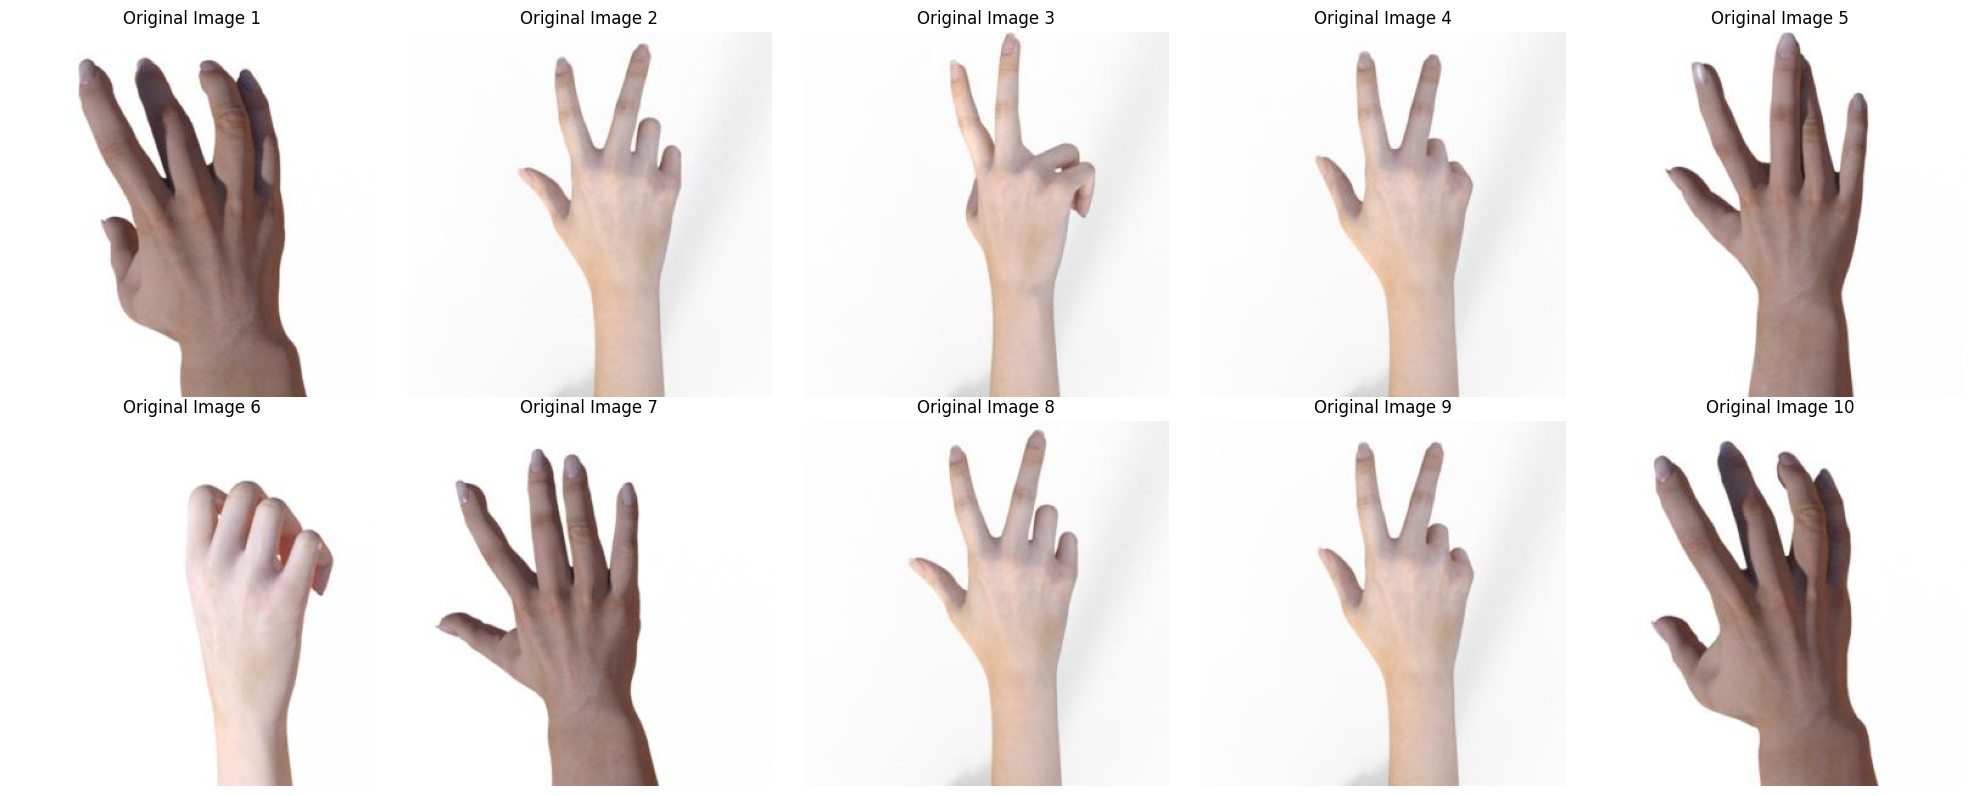

In [ ]:
import matplotlib.pyplot as plt
# Original form of 10 random images
selected_images = []

for i in range(10):
    selected_images.append(image_tensor[i*36])

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axs.flat):
    ax.imshow(selected_images[i].numpy().astype(np.uint8))
    ax.axis('off')
    ax.set_title(f"Original Image {i + 1}")
plt.tight_layout()
plt.show()

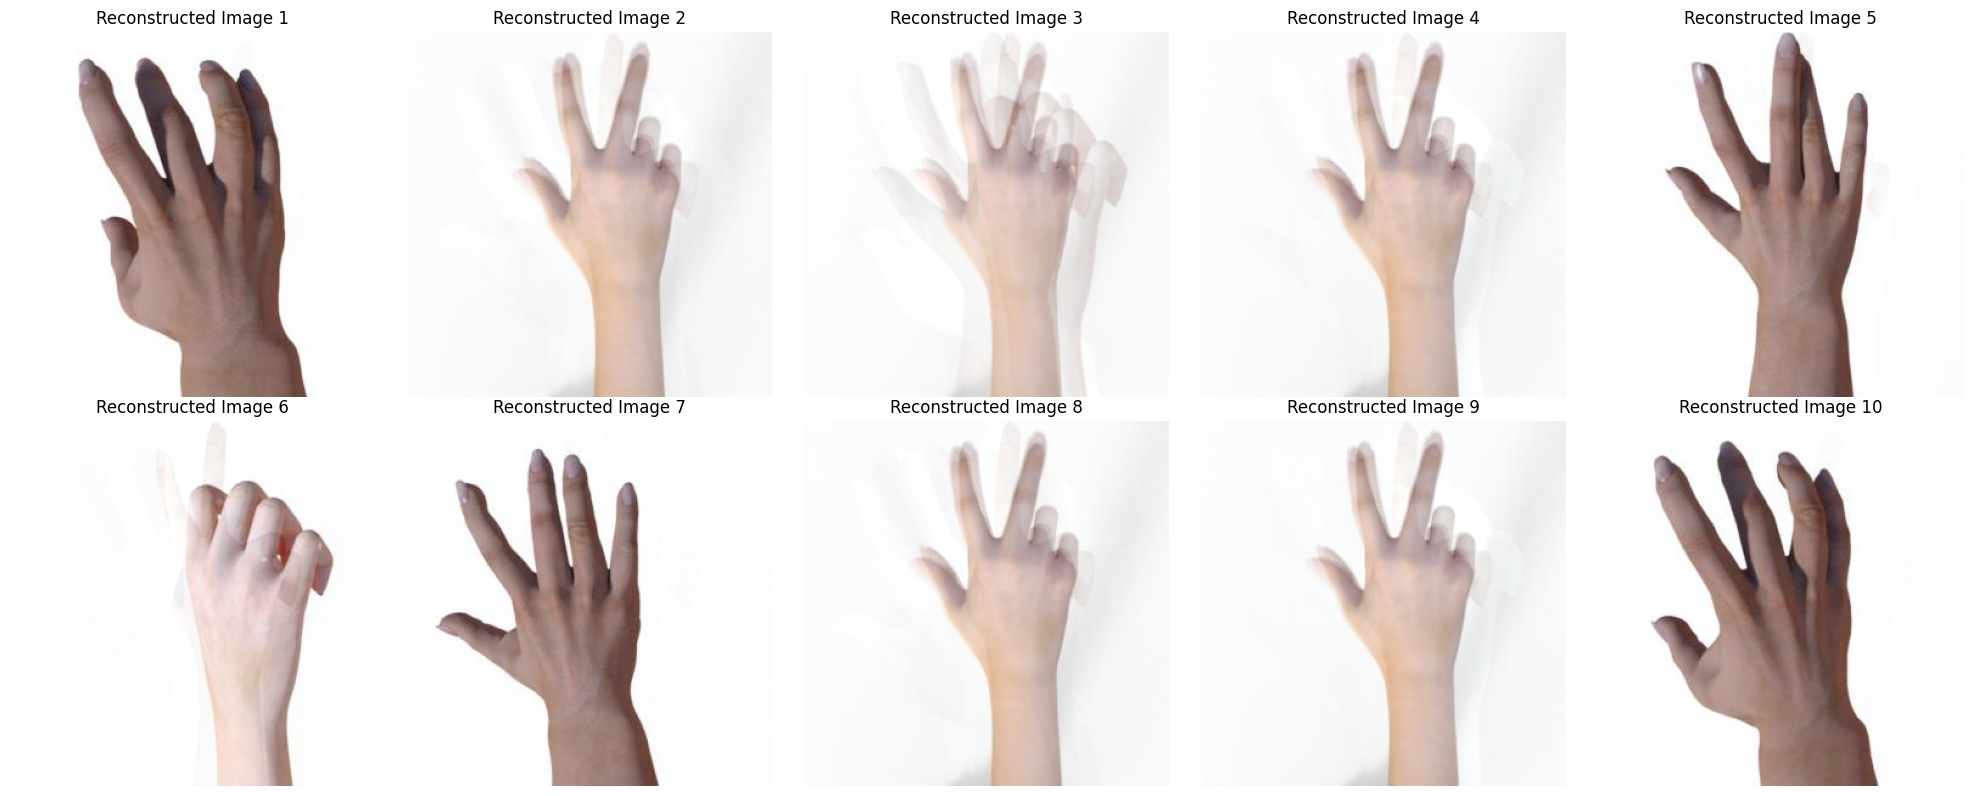

In [ ]:
# 10 images after PCA
pca = PCA(n_components=0.95)
selected_images = tf.convert_to_tensor(selected_images)
selected_images_flat = selected_images.numpy().reshape(selected_images.shape[0], -1)
selected_images_reduced = pca.fit_transform(selected_images_flat)

selected_images_reconstructed = pca.inverse_transform(selected_images_reduced)

reconstructed = selected_images_reconstructed.reshape(selected_images.shape)
reconstructed = np.clip(reconstructed, 0, 255)

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axs.flat):
    ax.imshow(reconstructed[i].astype(np.uint8))
    ax.axis('off')
    ax.set_title(f"Reconstructed Image {i + 1}")
plt.tight_layout()
plt.show()

#**3.**

###A.

In [ ]:
image_tensor_labels = []
X = []

for path in image_path:
    img = tf.keras.preprocessing.image.load_img(path)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32) / 255.0

    X.append(img_tensor)

    filename = os.path.basename(path)
    label = filename[0]
    image_tensor_labels.append(label)


In [ ]:
X = tf.convert_to_tensor(np.array(X), dtype=tf.float32)
X_flat = image_tensor.numpy().reshape(X.shape[0], -1)
pca_2d = PCA(n_components=2)
pca_2d.fit(X_flat)

print(sum(pca_2d.explained_variance_ratio_))

0.5518339648842812


About 55.18% of the variance is explained with the first 2 principal components.

###B.

In [ ]:
from sklearn.preprocessing import StandardScaler
# Doing PCA to the data, same below
scaler = StandardScaler()
X_reduced = pca_2d.transform(X_flat)
X_reduced.shape

(360, 2)

In [ ]:
#PC1 and PC2 confirmation, same below
PC1 = X_reduced[:, 0]
PC2 = X_reduced[:, 1]
PC1, PC2 = np.array(PC1), np.array(PC2)

image_tensor_labels = np.array(image_tensor_labels)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
# Function of plotting images
def plot_digits(X, y, min_distance=0.05, images=None, figsize=(12, 8)):
    if X.shape[0] != len(y):
        X = X.T
    X_normalized = MinMaxScaler().fit_transform(X)


    labels = np.unique(y)
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    n_labels = len(labels)
    numeric_y = np.array([label_to_index[label] for label in y])

    neighbors = np.array([[10., 10.]])
    plt.figure(figsize=figsize)
    cmap = plt.cm.jet
    ax = plt.gca()

    for label in labels:
        idx = label_to_index[label]
        plt.scatter(X_normalized[y == label, 0],
                    X_normalized[y == label, 1],
                    c=[cmap(idx / n_labels)],
                    label=label)

    plt.axis('off')

    for index, image_coord in enumerate(X_normalized):
        closest = np.linalg.norm(neighbors - image_coord, axis=1).min()
        if closest > min_distance:
            neighbors = np.r_[neighbors, [image_coord]]
            label_index = numeric_y[index]
            if images is None:
                plt.text(image_coord[0], image_coord[1], y[index],
                         color=cmap(label_index / len(labels)))

            else:
                image_size = int(np.sqrt(images.shape[1]))
                image = images[index]
                imagebox = AnnotationBbox(OffsetImage(image, cmap='binary', zoom=0.01), image_coord)
                ax.add_artist(imagebox)

    plt.show()

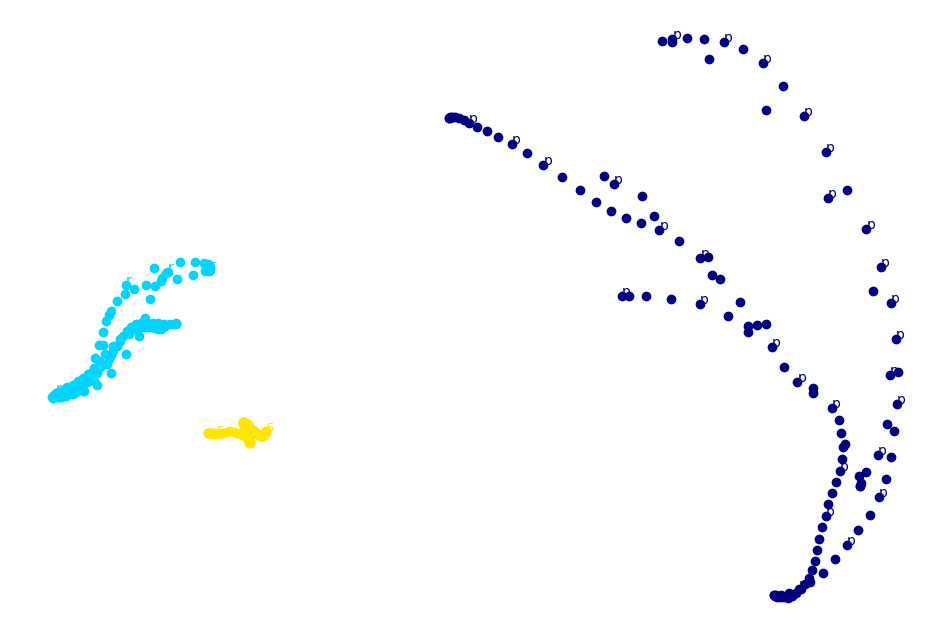

In [ ]:
#Plot without thumbnails, same below
plot_digits(np.array([PC1, PC2]).T, image_tensor_labels)

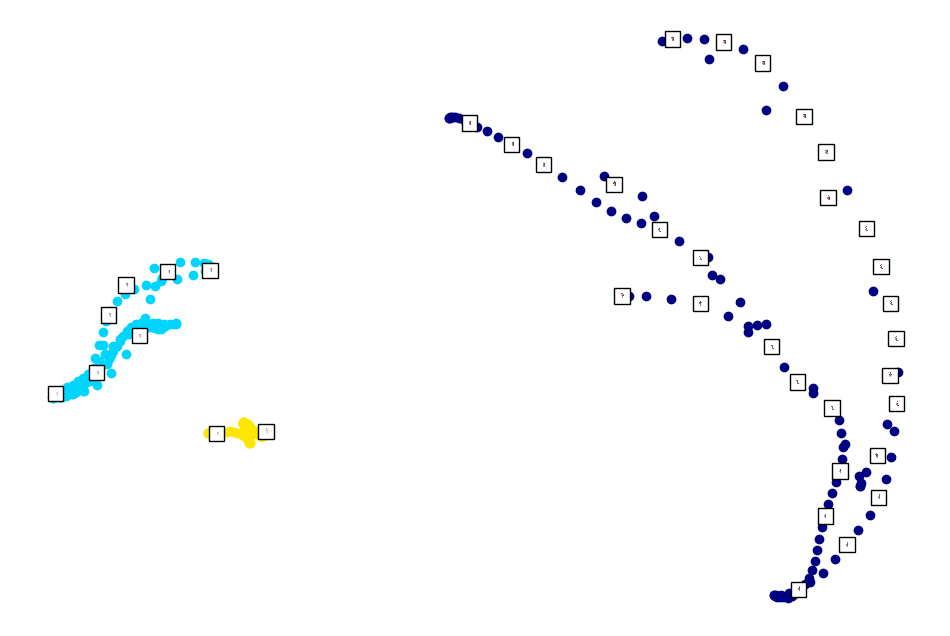

In [ ]:
# PCA scatter plots with thumbnails representing the images, same below
images_np = np.array(images)
plot_digits(np.array([PC1, PC2]).T, image_tensor_labels, images=images_np)

In [ ]:
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from umap.umap_ import UMAP

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_flat)

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

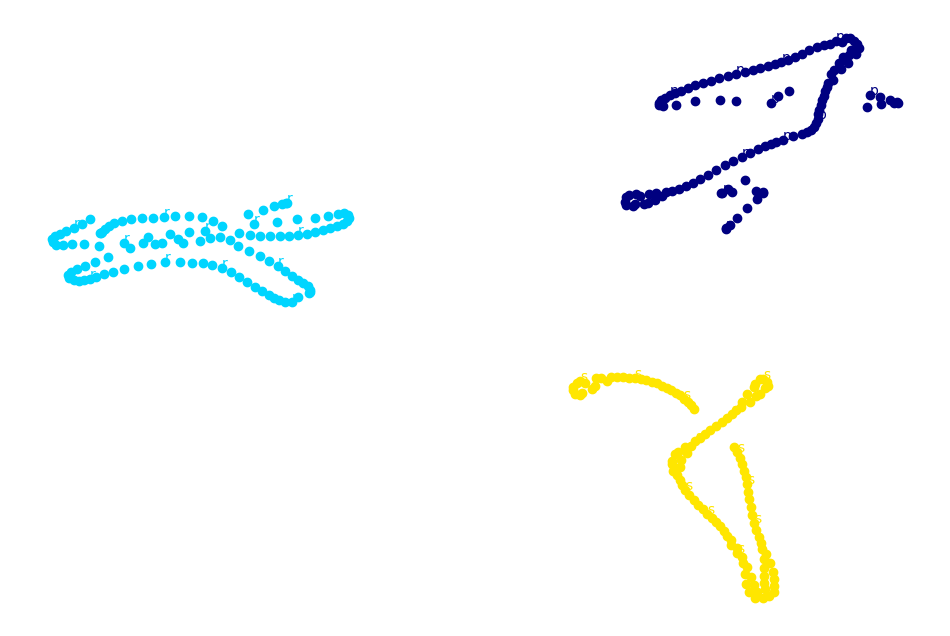

In [ ]:
plot_digits(X_tsne, image_tensor_labels)

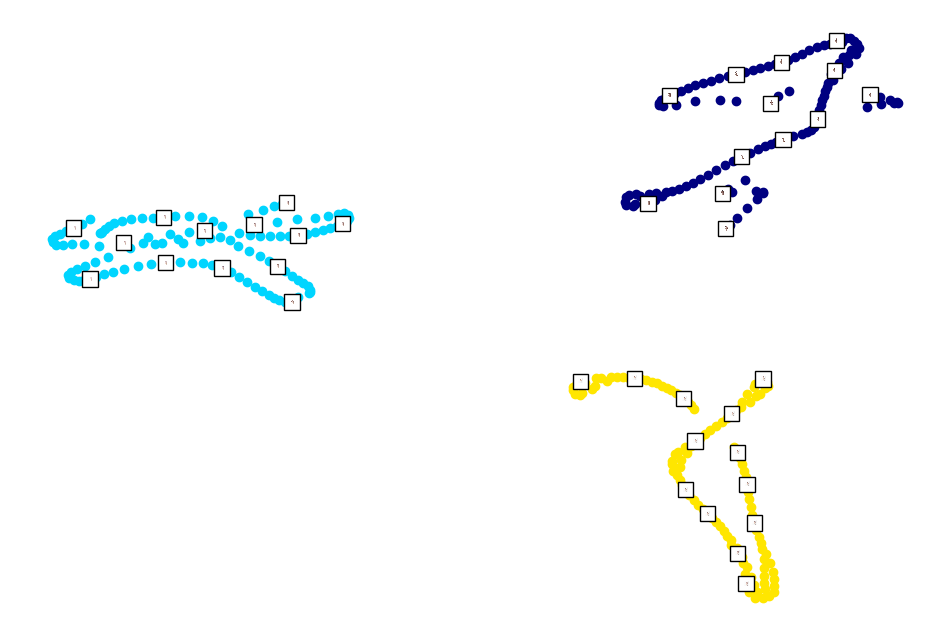

In [ ]:
plot_digits(X_tsne, image_tensor_labels, images=images_np)

In [ ]:
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=25, method='standard', random_state=42)
X_lle = lle.fit_transform(X_flat)

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

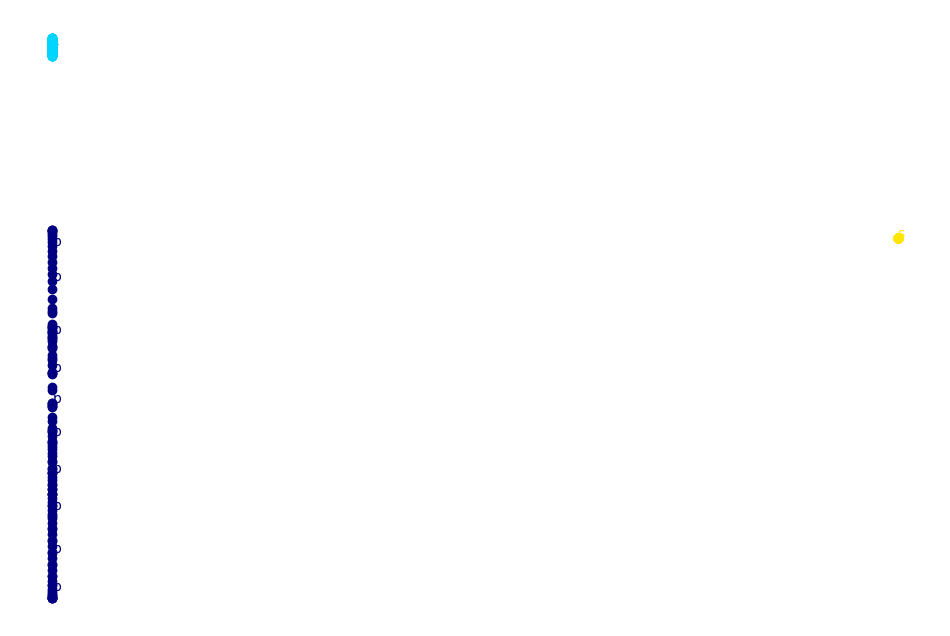

In [ ]:
plot_digits(X_lle, image_tensor_labels)

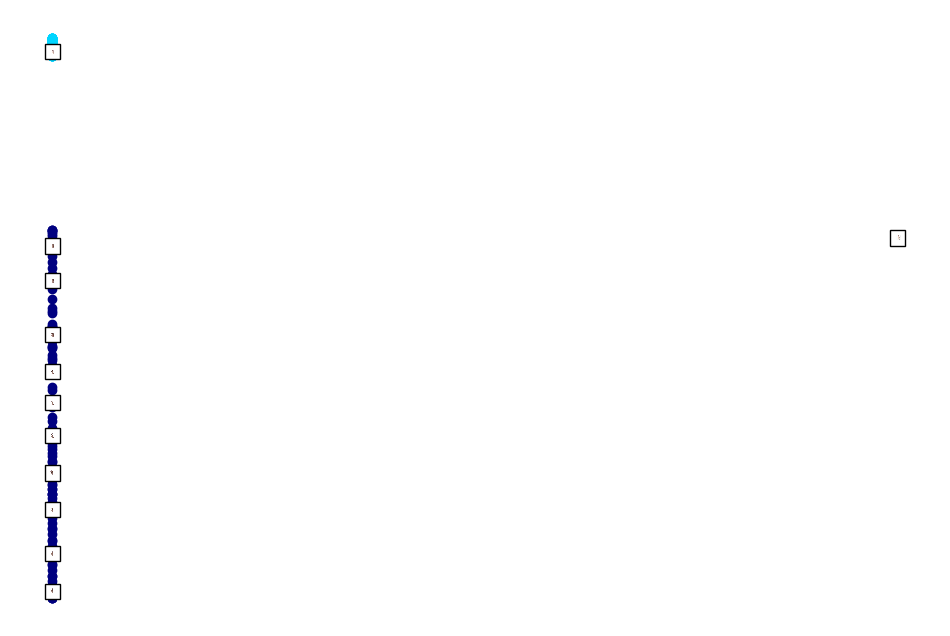

In [ ]:
plot_digits(X_lle, image_tensor_labels, images=images_np)

In [ ]:
UMAP = UMAP(n_components=2, random_state=42)
X_umap = UMAP.fit_transform(X_flat)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


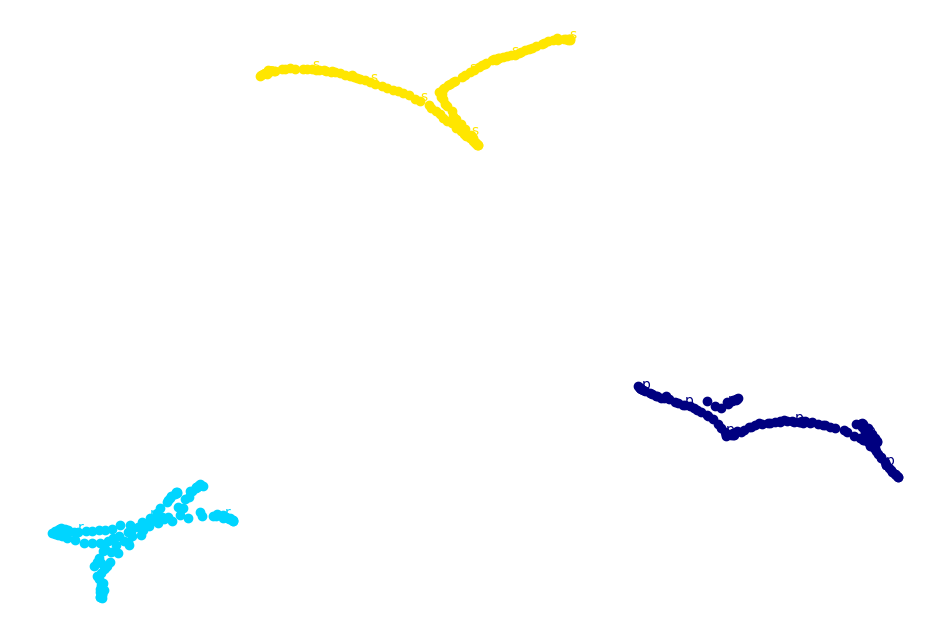

In [ ]:
plot_digits(X_umap, image_tensor_labels)

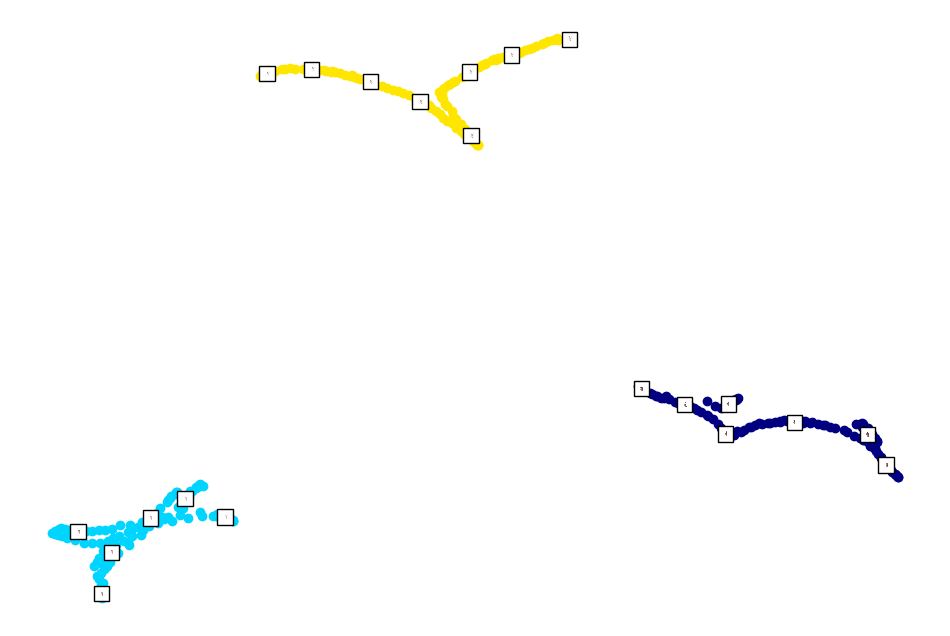

In [ ]:
plot_digits(X_umap, image_tensor_labels, images=images_np)

#**4. KMeans**

###A.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
# Function for finding the best k in KMeans, using silhouette score
def find_best_k(X, k_min=2, k_max=10):
    best_k = k_min
    best_score = -1
    scores = []
    for k in range(k_min, k_max+1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)

        if score > best_score:
            best_score = score
            best_k = k

            print(f'The best k is {best_k}, which has the silhoette score of {best_score:.4f}.')

    plt.plot(range(k_min, k_max+1), scores)
    plt.xlabel('k')
    plt.ylabel('Silhouette score')

    plt.show()
    print(f'Best k: {best_k}')

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:8

The best k is 2, which has the silhoette score of 0.4509.
The best k is 3, which has the silhoette score of 0.4573.


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


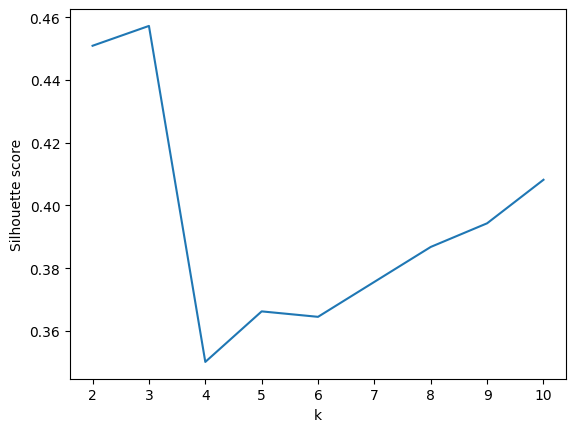

Best k: 3


In [ ]:
# Reduction of data
X_pca_95 = pca.fit_transform(X_flat)
# Finding the best k
find_best_k(X_pca_95)

The best k value is 3.

###B.

In [ ]:
#KMeans clustering, with the number of clusters 3
kmeans_3 = KMeans(n_clusters=3, random_state=42)
y_hat = kmeans_3.fit_predict(X_pca_95)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(image_tensor_labels)

print(image_tensor_labels)
print(y_encoded)

cm = confusion_matrix(y_encoded, y_hat)

row_ind, col_ind = linear_sum_assignment(-cm)

new_pred = np.zeros_like(y_hat)
for i, j in zip(col_ind, row_ind):
    new_pred[y_hat == i] = j

new_pred

['p' 's' 'p' 'p' 's' 's' 's' 'r' 'p' 'r' 's' 'p' 's' 'r' 'p' 's' 's' 'p'
 'p' 'r' 's' 'r' 's' 's' 'r' 'p' 'r' 's' 's' 'r' 'r' 'r' 's' 'r' 's' 'p'
 's' 'r' 'p' 'p' 'r' 's' 's' 'p' 's' 'p' 'r' 'r' 's' 'p' 'p' 'r' 'p' 'r'
 'p' 'r' 'r' 'p' 's' 'r' 'r' 'p' 'p' 'p' 'p' 'r' 's' 'p' 's' 'r' 'r' 'r'
 's' 's' 's' 'r' 'p' 'r' 'r' 's' 's' 'p' 'p' 'r' 'p' 'r' 's' 'r' 'p' 's'
 's' 'p' 's' 's' 'p' 'r' 'r' 'r' 's' 'r' 'r' 'r' 'r' 'p' 's' 'p' 'p' 's'
 's' 'p' 's' 'p' 'r' 'r' 'p' 'r' 'p' 's' 'p' 's' 'p' 's' 'r' 'r' 'p' 'r'
 'r' 's' 's' 'p' 'r' 'r' 'p' 'p' 'r' 'r' 'p' 's' 'r' 'p' 'r' 'r' 'p' 'r'
 'p' 'p' 's' 'p' 'r' 'r' 'r' 's' 'p' 'r' 's' 'r' 'p' 'r' 's' 's' 's' 'r'
 'p' 'p' 's' 's' 's' 'p' 'r' 'r' 's' 's' 'p' 'r' 'r' 'p' 's' 'p' 'r' 's'
 'r' 'r' 's' 's' 's' 'r' 's' 's' 's' 'r' 'p' 'r' 's' 'p' 's' 's' 'r' 'p'
 'p' 'p' 'p' 'r' 'p' 'p' 's' 'p' 'p' 'r' 'p' 's' 'r' 'p' 'p' 's' 's' 'p'
 'p' 'r' 'r' 'p' 'p' 'r' 's' 's' 'r' 'p' 'p' 'r' 'r' 'r' 's' 's' 'r' 's'
 'r' 'r' 'r' 'r' 'p' 'p' 'r' 'r' 'r' 's' 's' 'r' 's

array([2, 1, 2, 2, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 2,
       1, 2, 1, 1, 1, 2, 0, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 2, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 0, 1, 1, 2,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       2, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 2, 0, 1, 2, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 2,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
       0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 2, 2, 1, 2,
       1, 2, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 2,
       2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1, 1, 1, 2,

In [ ]:
from sklearn.metrics import accuracy_score
# Accuracy
accuracy = accuracy_score(y_encoded, new_pred)
accuracy

0.5

In [ ]:
# Confusion matrix
confusion_matrix(y_encoded, new_pred)

array([[ 60,   0,  60],
       [  0, 120,   0],
       [  0, 120,   0]])

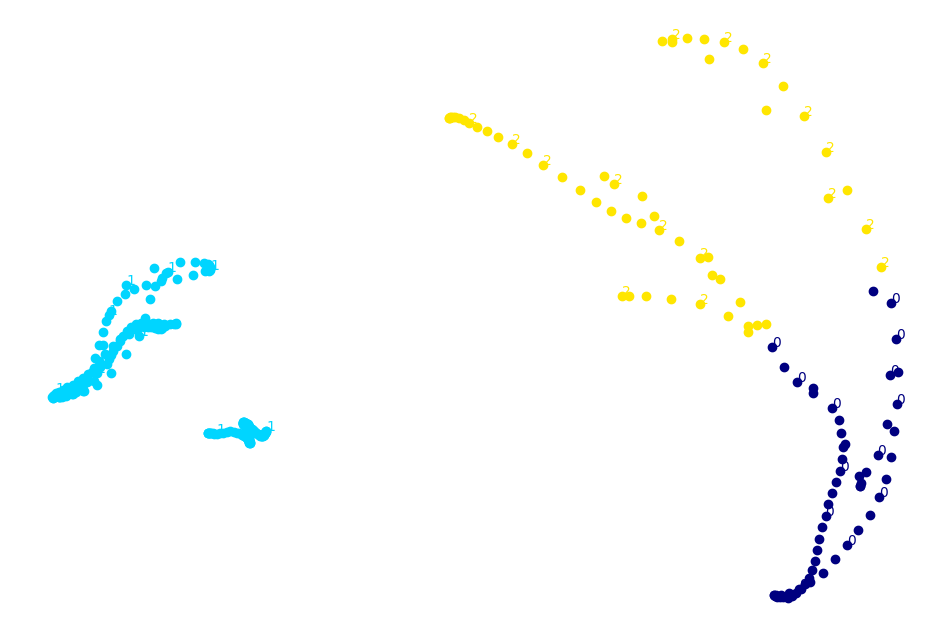

In [ ]:
# Visualization
pca_for_kmeans = PCA(n_components=2)
X_kmeans_pca = pca_for_kmeans.fit_transform(X_flat)

plot_digits(X_kmeans_pca, new_pred)

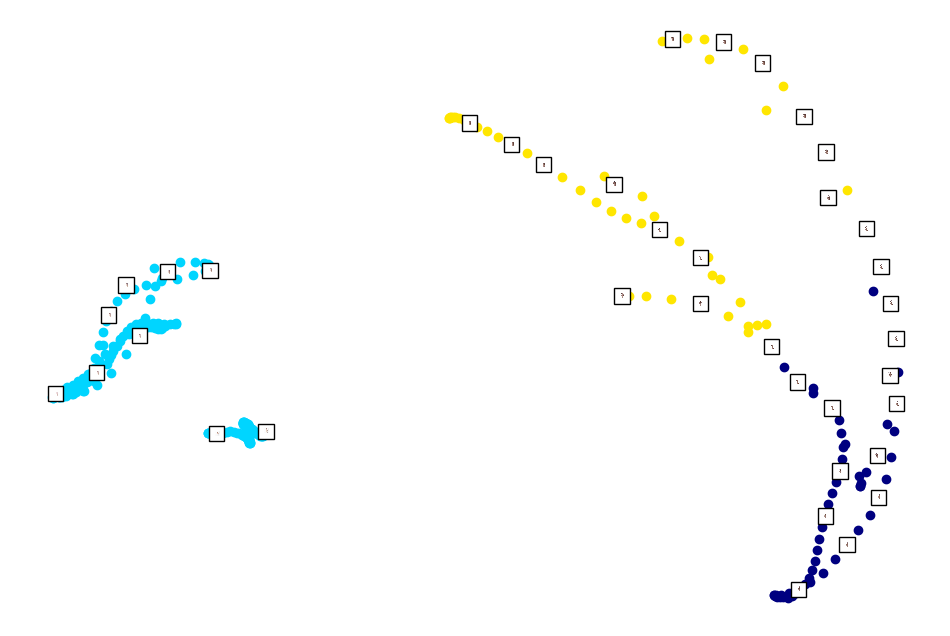

In [ ]:
plot_digits(X_kmeans_pca, new_pred, images=images_np)

#**5. EM**

###A.

In [ ]:
from sklearn.mixture import GaussianMixture

# Function finding the best k, but in EM version
def EM_find_best_k(X, k_min=2, k_max=10, criterion='bic'):
    bic_scores = []
    aic_scores = []
    ks = list(range(k_min, k_max + 1))

    for k in ks:
        gmm = GaussianMixture(n_components=k, random_state=42, max_iter=200, tol=1e-3)
        gmm.fit(X)
        bic_scores.append(gmm.bic(X))
        aic_scores.append(gmm.aic(X))

    bic_scores = np.array(bic_scores)
    aic_scores = np.array(aic_scores)

    if criterion == 'bic':
        best_k = ks[np.argmin(bic_scores)]
        scores = bic_scores
        ylabel = 'BIC'
    elif criterion == 'aic':
        best_k = ks[np.argmin(aic_scores)]
        scores = aic_scores
        ylabel = 'AIC'
    else:
        raise ValueError("criterion must be 'bic' or 'aic'")

    plt.figure(figsize=(8, 4))
    plt.plot(ks, scores, marker='o')
    plt.title(f'{ylabel} for different k values')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

    print(f'Best k according to {ylabel}: {best_k}')

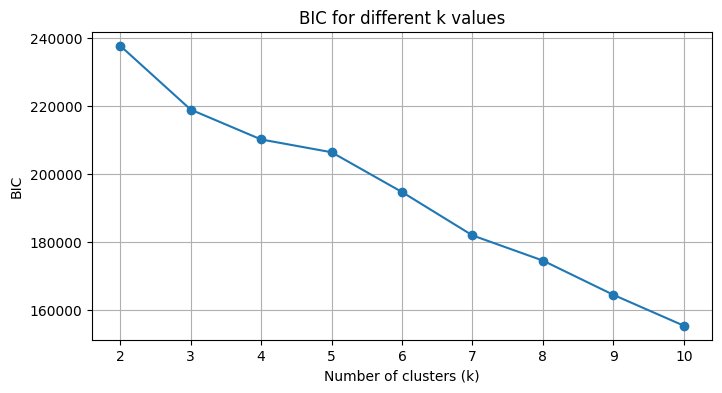

Best k according to BIC: 10


In [ ]:
# Dimension reduction
X_em_95 = pca.fit_transform(X_flat)
# Find the best k by BIC
EM_find_best_k(X_em_95, 2, 10)

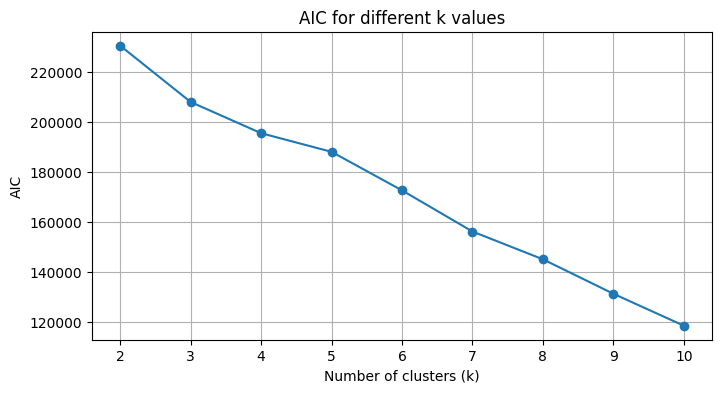

Best k according to AIC: 10


In [ ]:
# Find the best k by AIC
EM_find_best_k(X_em_95, 2, 10, 'aic')

###B and C

0.9611111111111111
[[106   0  14]
 [  0 120   0]
 [  0   0 120]]


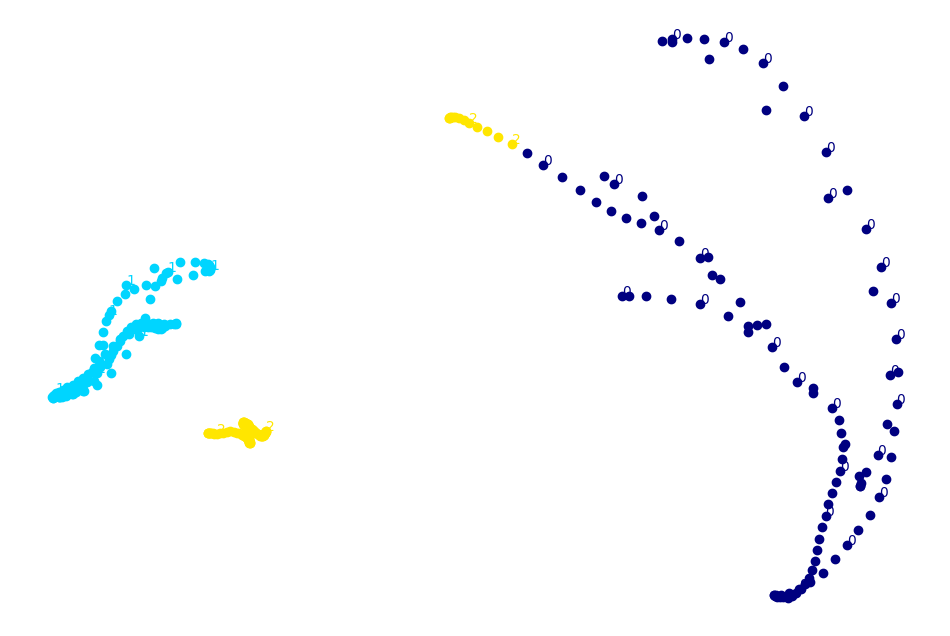

In [ ]:
em_3 = GaussianMixture(n_components=3, random_state=42, max_iter=200, tol=1e-3)
y_hat = em_3.fit_predict(X_em_95)

cm = confusion_matrix(y_encoded, y_hat)

row_ind, col_ind = linear_sum_assignment(-cm)

new_pred = np.zeros_like(y_hat)
for i, j in zip(col_ind, row_ind):
    new_pred[y_hat == i] = j

accuracy = accuracy_score(y_encoded, new_pred)
accuracy

print(accuracy)
print(confusion_matrix(y_encoded, new_pred))

pca_for_em = PCA(n_components=2)
X_em_pca = pca_for_em.fit_transform(X_flat)

plot_digits(X_em_pca, new_pred)

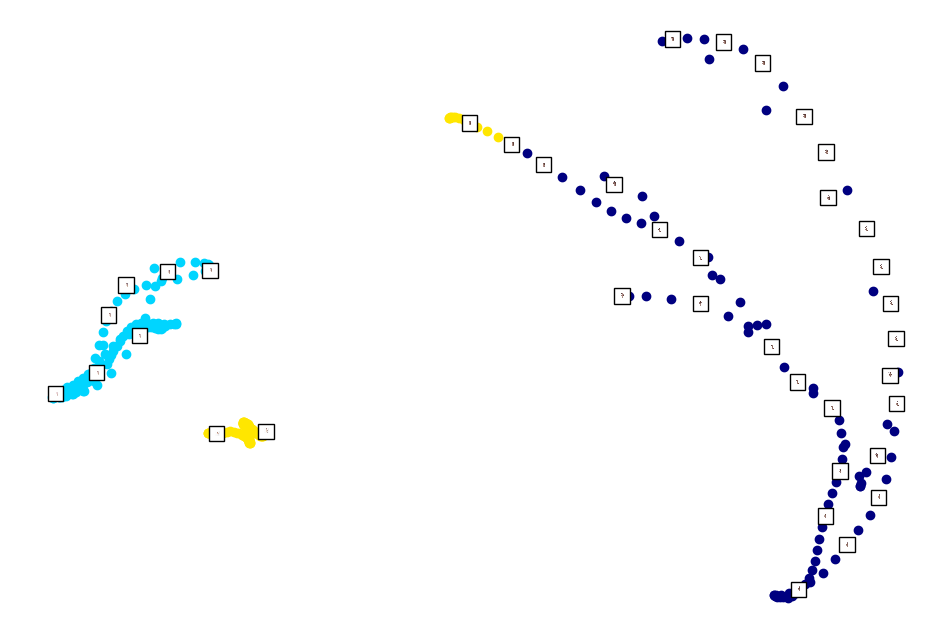

In [ ]:
plot_digits(X_em_pca, new_pred, images=images_np)

###D.

In [ ]:
import pandas as pd
# 20 new images
X_df = pd.DataFrame(X_em_95)
X_df_sample = X_df.sample(n=20, random_state=42)

X_df_flat = pca.inverse_transform(X_df_sample)
X_np_flat = X_df_flat
sample_images = X_np_flat.reshape((-1, 300, 300, 3))
sample_images = np.clip(sample_images, 0, 255)

fig, axs = plt.subplots(4, 5, figsize=(20, 8))
for i, ax in enumerate(axs.flat):
    ax.imshow(sample_images[i].astype(np.uint8))
    ax.axis('off')
    ax.set_title(f"Reconstructed Sample Image {i + 1}")
plt.tight_layout()
plt.show()

#**6.**

###A.

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout

In [ ]:
NN_model = Sequential()
NN_model.add(keras.layers.Flatten(input_shape=[100, 100, 3]))
NN_model.add(keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
NN_model.add(Dropout(0.5))
NN_model.add(keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
NN_model.add(Dropout(0.3))
NN_model.add(keras.layers.Dense(3, activation='softmax'))
NN_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 30000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       7,680,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,713,539 (29.42 MB)

 Trainable params: 7,713,539 (29.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rocks_zip_2 = '120 Rocks/120 Rocks.zip'

# Unzipping
if os.path.exists(rocks_zip_2):
    extract_to = os.path.splitext(rocks_zip_2)[0]

    with zipfile.ZipFile(rocks_zip_2, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    os.remove(rocks_zip_2)

else:
    print('File already extracted')

File already extracted


In [ ]:
val_image_path = glob.glob('/kaggle/input/rockpaperscissor/RockPaperScissor/90Val/*.jpg')

val_images = [tf.keras.preprocessing.image.load_img(p, target_size=(100, 100)) for p in val_image_path]

zoomed_images = [tf.keras.preprocessing.image.load_img(p, target_size=(100, 100)) for p in image_path]
zoomed_image_tensor = tf.convert_to_tensor(np.array(zoomed_images), dtype=tf.float32)

val_image_tensor = tf.convert_to_tensor(np.array(val_images), dtype=tf.float32)

val_flat_images = val_image_tensor.numpy().reshape(val_image_tensor.shape[0], -1)
val_flat_images.shape

(93, 30000)

In [ ]:
image_tensor_labels = []
val_image_tensor_labels = []
X = []
X_val = []

for path in image_path:
    img = tf.keras.preprocessing.image.load_img(path, target_size=(100, 100))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    zoomed_img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32) / 255.0

    X.append(zoomed_img_tensor)

    filename = os.path.basename(path)
    label = filename[0]
    image_tensor_labels.append(label)

for path in val_image_path:
    img = tf.keras.preprocessing.image.load_img(path, target_size=(100, 100))
    val_img_array = tf.keras.preprocessing.image.img_to_array(img)
    val_img_tensor = tf.convert_to_tensor(val_img_array, dtype=tf.float32) / 255.0

    X_val.append(val_img_tensor)

    filename = os.path.basename(path)
    label = filename[0]
    val_image_tensor_labels.append(label)

image_tensor_labels = np.array(image_tensor_labels)
val_image_tensor_labels = np.array(val_image_tensor_labels)
X = np.array(X)
X_val = np.array(X_val)


In [ ]:

import tensorflow as tf
len(tf.config.list_physical_devices('GPU'))

2

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(image_tensor_labels)
y_val_encoded = encoder.transform(val_image_tensor_labels)

NN_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

start_time = time.time()
history = NN_model.fit(
    X, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=100,
    batch_size=5,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
end_time = time.time()
print(f"Training time: {end_time - start_time:.4f} sec.")

Epoch 1/100


I0000 00:00:1745004055.707858    2028 service.cc:148] XLA service 0x7ed394006cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745004055.707905    2028 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745004055.707909    2028 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745004055.843039    2028 cuda_dnn.cc:529] Loaded cuDNN version 90300


49/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3631 - loss: 36.5729

I0000 00:00:1745004057.421539    2028 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3718 - loss: 33.7390 - val_accuracy: 0.3333 - val_loss: 2.5108 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3741 - loss: 3.9037 - val_accuracy: 0.3333 - val_loss: 1.5895 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3281 - loss: 1.5794 - val_accuracy: 0.3333 - val_loss: 1.5458 - learning_rate: 0.0010
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3317 - loss: 1.5630 - val_accuracy: 0.3333 - val_loss: 1.5172 - learning_rate: 0.0010
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3240 - loss: 1.5089 - val_accuracy: 0.3333 - val_loss: 1.5628 - learning_rate: 0.0010
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3459 - loss: 1.5120 - val_accuracy: 0.3333 - val_loss: 1.4684 - learning_rate: 0.0010
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3316 - loss: 1.4604 - val_accuracy: 0.3

The training time is about 37,367.5 milliseconds.

###B.

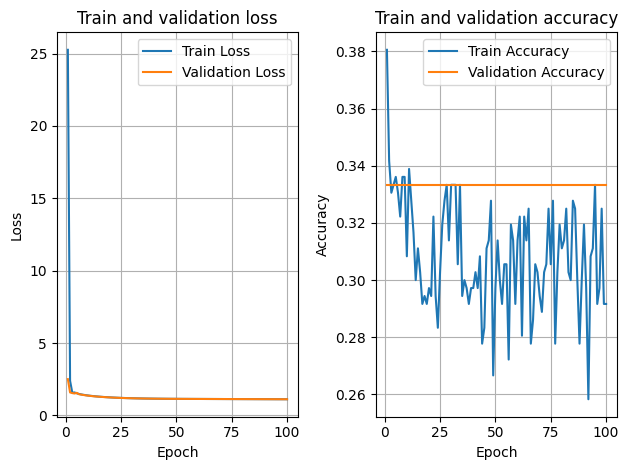

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Train and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Train and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Here the training loss and validation loss reduce but train accuracy is shaking.

###C.
There are 7,713,539 parameters, with 256+128+3=387 bias parameters.

###D.

In [ ]:
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
import gc

def extract_activations(model, layer, input_data, reduce_dim=2, flatten=True):

    intermediate = Model(inputs=model.input,
                         outputs=model.get_layer(layer).output)

    activations = intermediate.predict(input_data)

    if flatten:
        activations = activations.reshape((activations.shape[0], -1))

    if reduce_dim is not None:
        pca = PCA(n_components=reduce_dim, random_state=42)
        activations = pca.fit_transform(activations)

    return activations

In [ ]:
def activation_EM(activations, true_labels, max_clusters=10, N=3, title_suffix=''):
    BICs, AICs = [], []
    for n in range(1, max_clusters+1):
        em = GaussianMixture(n_components=n, random_state=42)
        em.fit(activations)
        BICs.append(em.bic(activations))
        AICs.append(em.aic(activations))

    plt.figure(figsize=(16, 9))
    plt.plot(range(1, max_clusters + 1), BICs, label='BIC')
    plt.plot(range(1, max_clusters + 1), AICs, label='AIC')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Score')
    plt.title(f'BIC/AIC for cluster {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()

    em_fixed = GaussianMixture(n_components=N, random_state=42)
    cluster_labels = em_fixed.fit_predict(activations)

    def match_labels(y_true, y_pred):
        D = max(y_pred.max(), y_true.max()) + 1
        cost_matrix = np.zeros((D, D), dtype=np.int64)
        for i in range(len(y_true)):
            cost_matrix[y_pred[i], y_true[i]] += 1
        row_ind, col_ind = linear_sum_assignment(-cost_matrix)  # maximize accuracy
        mapping = {row: col for row, col in zip(row_ind, col_ind)}
        matched = np.array([mapping[label] for label in y_pred])
        return matched

    matched_labels = match_labels(true_labels, cluster_labels)

    acc = accuracy_score(true_labels, matched_labels)
    cm = confusion_matrix(true_labels, matched_labels)

    print(f"EM clustering accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    reduced = activations

    plt.figure(figsize=(4, 3))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=cluster_labels, cmap='viridis', s=15)
    plt.title(f'EM (n={N}) {title_suffix}')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.colorbar(label='Cluster ID')
    plt.grid(True)
    plt.show()

    K.clear_session()
    gc.collect()
    tf.keras.backend.clear_session()

In [ ]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Flatten, Dense

inputs = Input(shape=(100, 100, 3))
x = Dense(256, activation='relu', name='dense_1')(inputs)
x = Dense(128, activation='relu', name='dense_2')(x)
outputs = Dense(3, activation='softmax')(x)

NN_model = Model(inputs=inputs, outputs=outputs)
NN_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100, 100, 256)       │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100, 100, 128)       │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100, 100, 3)         │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,307 (134.01 KB)

 Trainable params: 34,307 (134.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(NN_model.layers)

[<InputLayer name=input_layer_1, built=True>, <Dense name=dense_1, built=True>, <Dense name=dense_2, built=True>, <Dense name=dense_3, built=True>]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
(360, 100, 100, 3)
(1, 100, 100, 3)
[<InputLayer name=input_layer_1, built=True>, <Dense name=dense_1, built=True>, <Dense name=dense_2, built=True>, <Dense name=dense_3, built=True>]
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


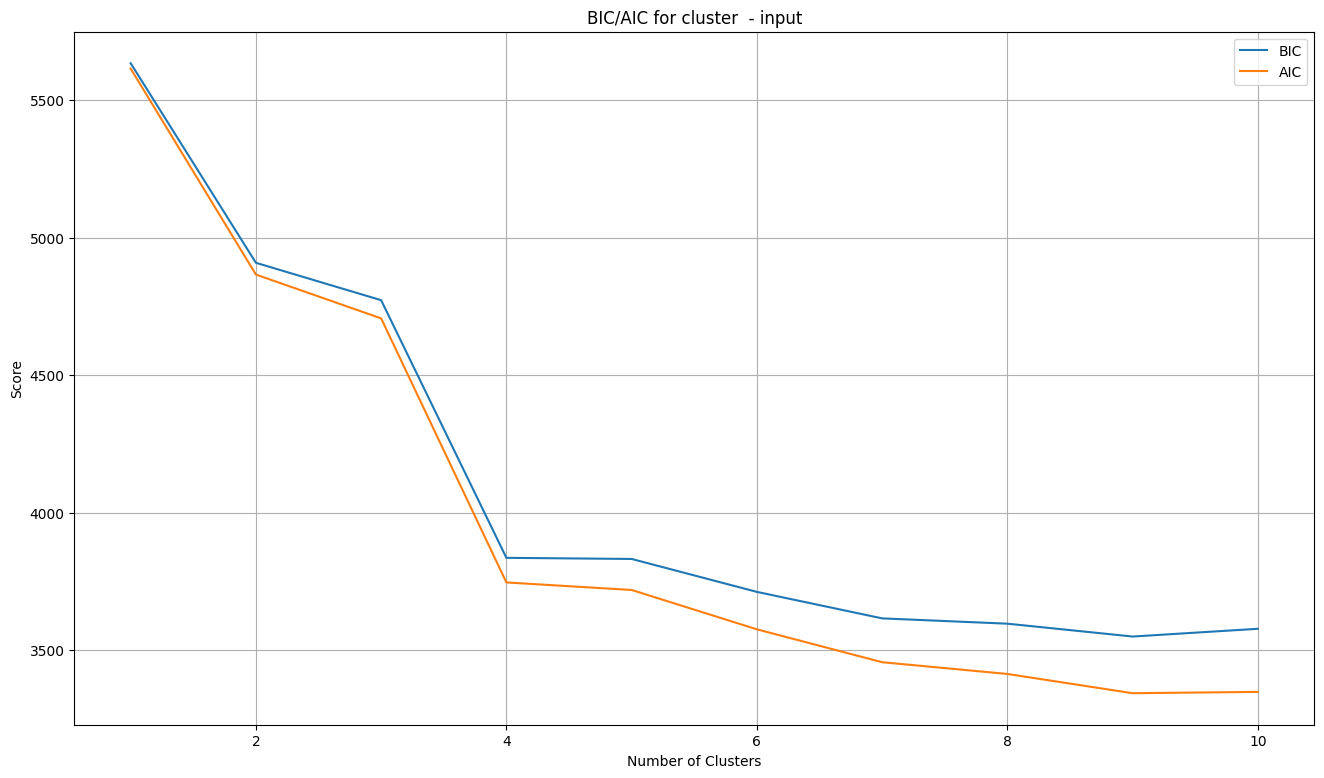

EM clustering accuracy: 0.5250
Confusion Matrix:
[[ 69   0  51]
 [  0 120   0]
 [  0 120   0]]


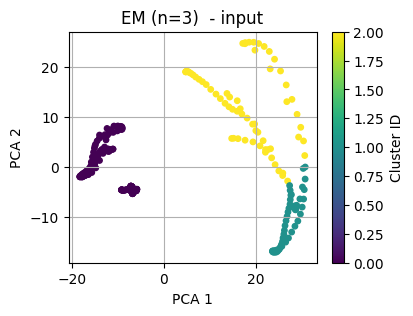

In [ ]:
# Using EM around the middle of training
NN_model.predict(X[:1])
print(X.shape)
print(X[:1].shape)

print(NN_model.layers)

input_dense = extract_activations(NN_model, NN_model.layers[0].name, input_data=X)
activation_EM(input_dense, true_labels=y_train_encoded, title_suffix=" - input")

In [ ]:
print(X.shape)

(360, 100, 100, 3)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


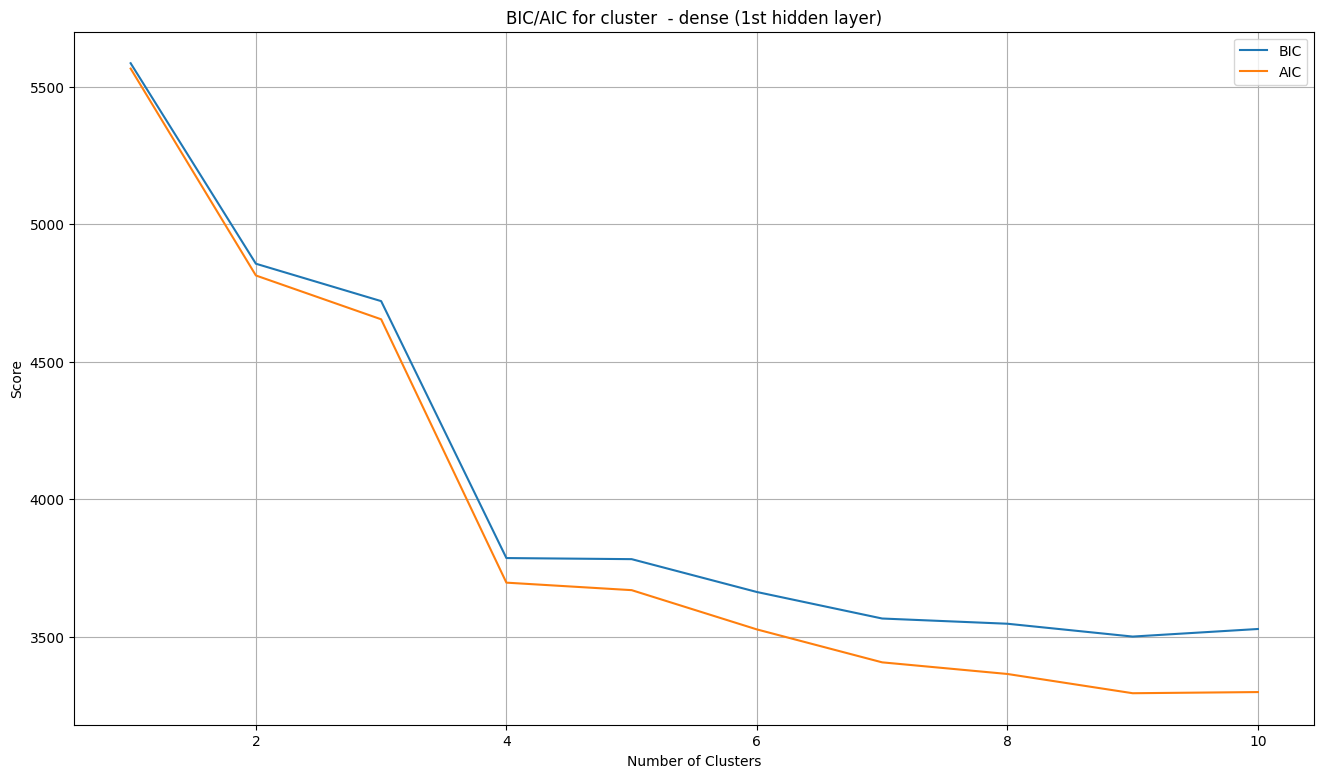

EM clustering accuracy: 0.5250
Confusion Matrix:
[[ 69   0  51]
 [  0 120   0]
 [  0 120   0]]


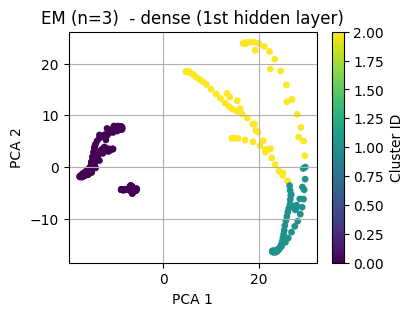

In [ ]:
# After training
first_dense = extract_activations(NN_model, NN_model.layers[1].name, X)
activation_EM(first_dense, true_labels=y_train_encoded, title_suffix=" - dense (1st hidden layer)")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


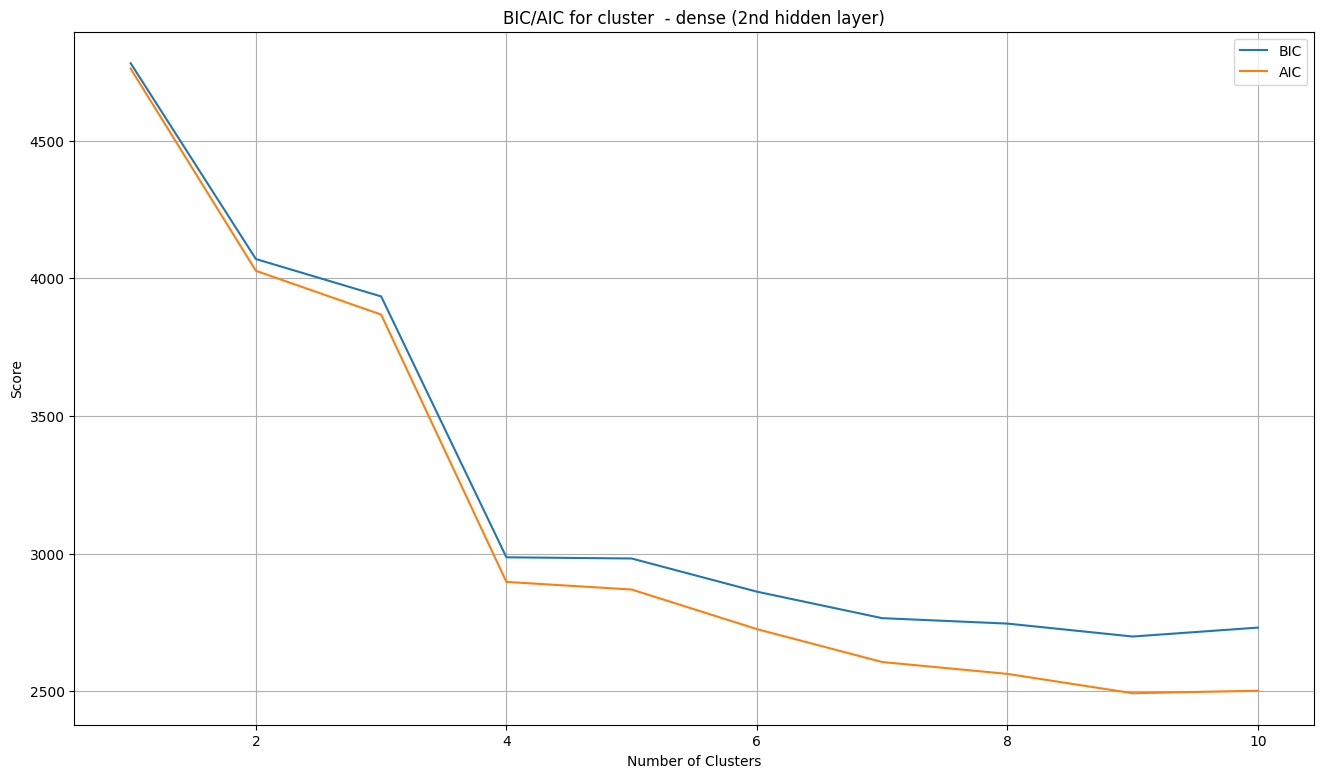

EM clustering accuracy: 0.5250
Confusion Matrix:
[[ 69   0  51]
 [  0 120   0]
 [  0 120   0]]


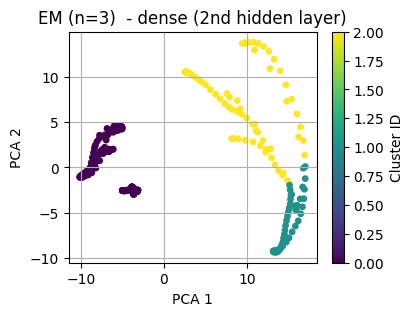

In [ ]:

second_dense = extract_activations(NN_model, NN_model.layers[2].name, X)
activation_EM(second_dense, y_train_encoded, title_suffix=" - dense (2nd hidden layer)")

The best clustering number is 9.
Here the clustering accuracy hardly changes, with the EM clustering results almost the same. The biggest reason leading to this is that the scatters are usually concentrated in a particular area, instead of distributed everywhere.